# KMeans + Logistic Regression

# K-Means

### Finding Optimal Value of k in K-Means

In [1]:
Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)
garnet <- "#6B0D0E"
gold   <- "#F8C23A"

In [2]:
train_data <- read.csv("../Pima-Indians-Diabetes-Dataset/train_data_imputed.csv")
test_data <- read.csv("../Pima-Indians-Diabetes-Dataset/test_data_imputed.csv")

train_x <- subset(train_data, select = -Outcome)
train_y <- train_data$Outcome

test_x <- subset(test_data, select = -Outcome)
test_y <- test_data$Outcome


In [3]:
# ============================
# Split X and Y
# ============================

# ============================
# Z-score Scaling
# ============================

train_mean <- apply(train_x, 2, mean)
train_sd <- apply(train_x, 2, sd)

train_scaled <- scale(
  train_x,
  center = train_mean,
  scale = train_sd
)

test_scaled <- scale(
  test_x,
  center = train_mean,
  scale = train_sd
)

##### Elbow Method

In [4]:
set.seed(123)

wss <- numeric(19)

for (i in 1:19) {

  km <- kmeans(
    train_scaled,
    centers = i,
    nstart = 25
  )

  wss[i] <- km$tot.withinss
}

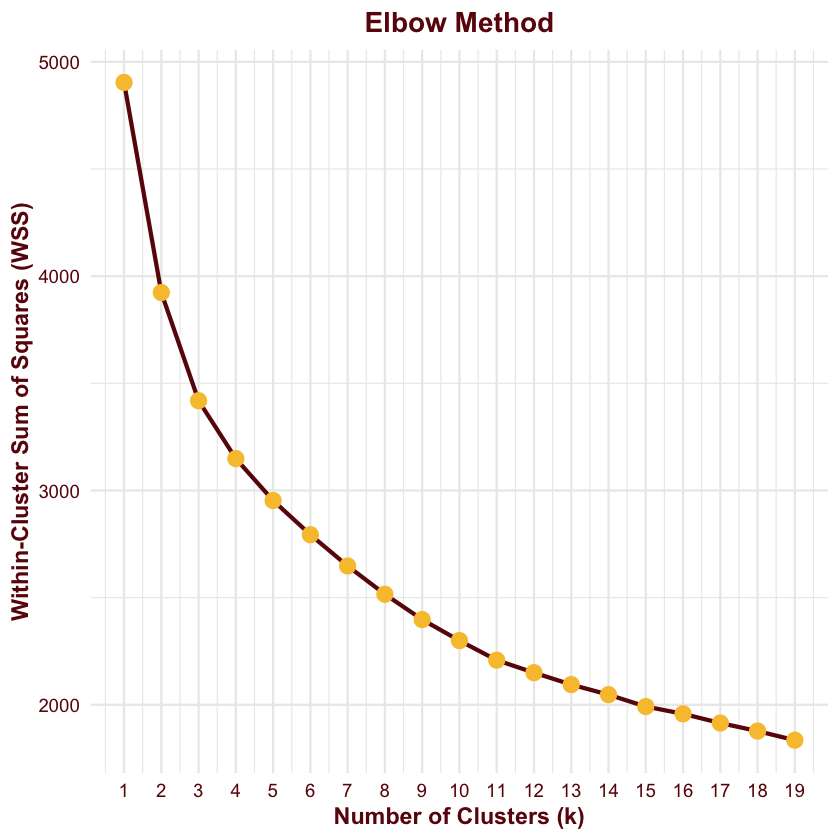

In [5]:
library(ggplot2)

Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)

elbow_df <- data.frame(
  k = 1:19,
  WSS = wss
)

ggplot(elbow_df,
       aes(x = k, y = WSS)) +

  geom_line(
    linewidth = 1.2,
    color = Garnet
  ) +

  geom_point(
    size = 4,
    color = Gold
  ) +

  scale_x_continuous(breaks = 1:19) +

  labs(
    title = "Elbow Method",
    x = "Number of Clusters (k)",
    y = "Within-Cluster Sum of Squares (WSS)"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5,
      color = Garnet
    ),
    axis.title = element_text(
      face = "bold",
      color = Garnet
    ),
    axis.text = element_text(
      color = Garnet
    ) 
  )

In [6]:
improvement_table <- data.frame(
  From_k = 1:18,
  To_k = 2:19,
  WSS_Drop = round(
    wss[1:18] - wss[2:19],
    2
  ),
  Percent_Drop = round(
    (wss[1:18] - wss[2:19]) /
    wss[1:18] * 100,
    2
  )
)

improvement_table

From_k,To_k,WSS_Drop,Percent_Drop
<int>,<int>,<dbl>,<dbl>
1,2,980.36,19.99
2,3,504.80,12.87
3,4,270.18,7.90
4,5,195.42,6.21
5,6,159.57,5.40
6,7,145.89,5.22
7,8,131.89,4.98
8,9,118.17,4.70
9,10,98.10,4.09


##### Silhouette Plot

In [7]:
library(factoextra)
library(cluster)

Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/en/product/practical-guide-to-principal-component-methods-in-r/



In [8]:
library(cluster)

sil_width <- numeric(19)

for(k in 2:20){

  km <- kmeans(
    train_scaled,
    centers = k,
    nstart = 25
  )

  ss <- silhouette(
    km$cluster,
    dist(train_scaled)
  )

  sil_width[k - 1] <- mean(ss[, 3])
}

sil_df <- data.frame(
  k = 2:20,
  Avg_Silhouette = round(sil_width, 4)
)

sil_df

k,Avg_Silhouette
<int>,<dbl>
2,0.2039
3,0.2008
4,0.1825
5,0.1397
6,0.1332
7,0.1358
8,0.1407
9,0.1519
10,0.1519


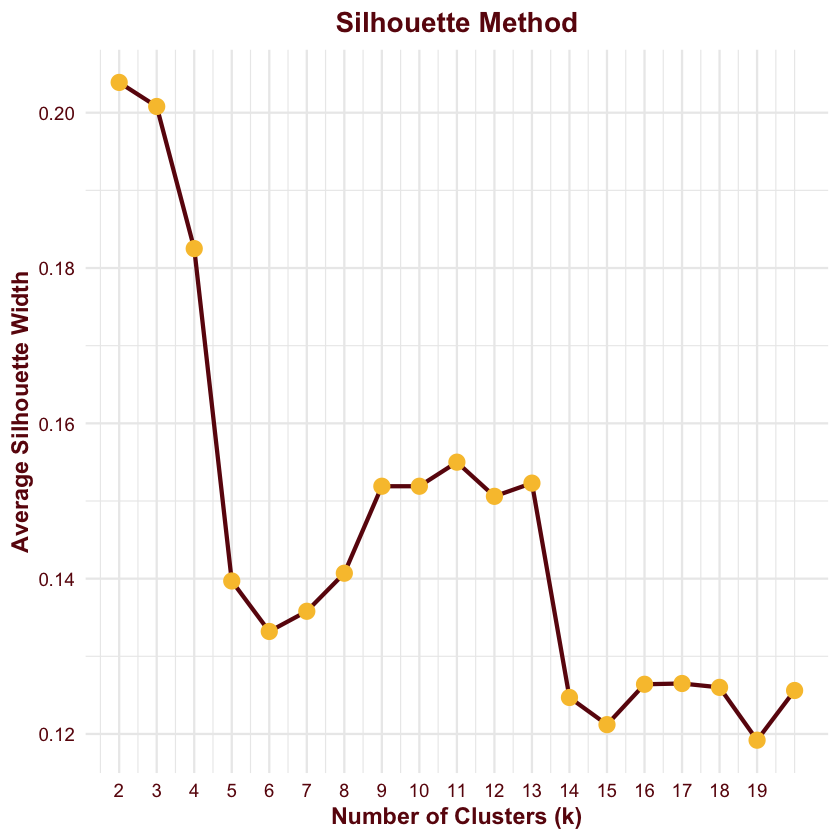

In [9]:
library(ggplot2)

Garnet <- rgb(107, 13, 14, maxColorValue = 255)
Gold   <- rgb(248, 194, 58, maxColorValue = 255)

best_k <- sil_df$k[which.max(sil_df$Avg_Silhouette)]

ggplot(
  sil_df,
  aes(x = k, y = Avg_Silhouette)
) +

  geom_line(
    linewidth = 1.2,
    color = Garnet
  ) +

  geom_point(
    size = 4,
    color = Gold
  ) +

  scale_x_continuous(
    breaks = 2:19
  ) +

  labs(
    title = "Silhouette Method",
    x = "Number of Clusters (k)",
    y = "Average Silhouette Width"
  ) +

  theme_minimal(base_size = 14) +

  theme(
    plot.title = element_text(
      face = "bold",
      hjust = 0.5,
      color = Garnet
    ),
    axis.title = element_text(
      face = "bold",
      color = Garnet
    ),
    axis.text = element_text(
      color = Garnet
    )
  )

In [10]:
# Based on the silhouette method, the optimal number of clusters is determined to be k = 2, as it yields the highest average silhouette width among the tested values of k while the elbow method did not provide a clear indication of the optimal number of clusters. 
k <- 2

### Cluster-Augmented Logistic Regression

##### Add cluster label

In [11]:
data <- read.csv("../Pima-Indians-Diabetes-Dataset/diabetes_imputed.csv")

X <- data[, names(data) != "Outcome"]
Y <- data$Outcome

X_scaled <- scale(X)

data_scaled <- data.frame(
  X_scaled,
  Outcome = Y
)

In [12]:
set.seed(123)

kmeans_model <- kmeans(
  X_scaled,
  centers = k,
  nstart = 25
)

In [13]:
data_clustered <- data.frame(
  data_scaled,
  Cluster = kmeans_model$cluster
)

In [14]:
head(data_clustered)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,0.6395305,0.8634573,-0.03536589,0.6446679,0.5609061,0.1676966,0.4681869,1.42506672,1,2
2,-0.8443348,-1.2046927,-0.53098610,-0.0276832,-0.3006457,-0.8498977,-0.3648230,-0.19054773,0,1
3,1.2330766,2.0124295,-0.69619284,0.4205509,0.5609061,-1.3296207,0.6040037,-0.10551539,1,2
4,-0.8443348,-1.0733816,-0.53098610,-0.7000343,-0.7090128,-0.6318417,-0.9201630,-1.04087112,0,1
5,-1.1411079,0.5023517,-2.67867369,0.6446679,0.1237493,1.5487174,5.4813370,-0.02048305,1,1
6,0.3427574,-0.1870316,0.12984085,-0.2254153,-0.3006457,-0.9952683,-0.8175458,-0.27558007,0,1


In [15]:
dim(data_clustered)

[1] 768  10

##### Check Each Cluster Distribution

In [16]:
cluster_summary <- table(
  data_clustered$Cluster,
  data_clustered$Outcome
)

cluster_summary

   
      0   1
  1 351  56
  2 149 212

In [17]:
set.seed(123)

index <- sample(
  1:nrow(data_clustered),
  size = 0.8 * nrow(data_clustered)
)

train_data <- data_clustered[index, ]
test_data  <- data_clustered[-index, ]

##### Logistic Regression

In [18]:
model_logistic <- glm(
  Outcome ~ .,
  data = train_data,
  family = binomial
)

summary(model_logistic)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_data)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -1.54666    0.55122  -2.806 0.005018 ** 
Pregnancies               0.31601    0.13002   2.430 0.015078 *  
Glucose                   0.88664    0.14085   6.295 3.07e-10 ***
BloodPressure            -0.15234    0.13180  -1.156 0.247743    
SkinThickness             0.30565    0.14406   2.122 0.033859 *  
Insulin                   0.56935    0.15988   3.561 0.000369 ***
BMI                       0.35022    0.14210   2.465 0.013719 *  
DiabetesPedigreeFunction  0.20855    0.10883   1.916 0.055340 .  
Age                       0.06801    0.13565   0.501 0.616120    
Cluster                   0.44611    0.36411   1.225 0.220503    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residua

In [19]:
# ============================
# Prediction (Test)
# ============================

prob_test <- predict(
  model_logistic,
  newdata = test_data,
  type = "response"
)

pred_test <- ifelse(
  prob_test > 0.42,
  1,
  0
)

# ============================
# Confusion Matrix (Test)
# ============================

cm_test <- table(
  Actual = test_data$Outcome,
  Predicted = pred_test
)

print(cm_test)

# ============================
# Evaluation Metrics (Test)
# ============================

accuracy_test <- sum(diag(cm_test)) /
  sum(cm_test)

TP_test <- cm_test["1", "1"]
TN_test <- cm_test["0", "0"]
FP_test <- cm_test["0", "1"]
FN_test <- cm_test["1", "0"]

precision_test <- TP_test /
  (TP_test + FP_test)

recall_test <- TP_test /
  (TP_test + FN_test)

f1_test <- 2 *
  precision_test *
  recall_test /
  (precision_test + recall_test)

# ============================
# Results (Test)
# ============================

cat(
  "\nTest Data Outcome:",
  "\nAccuracy =", round(accuracy_test, 4),
  "\nPrecision =", round(precision_test, 4),
  "\nRecall =", round(recall_test, 4),
  "\nF1 Score =", round(f1_test, 4)
)

      Predicted
Actual  0  1
     0 85 17
     1 15 37

Test Data Outcome: 
Accuracy = 0.7922 
Precision = 0.6852 
Recall = 0.7115 
F1 Score = 0.6981

In [20]:
BIC(model_logistic)

[1] 604.7016

### Noise-reduced Full LR

In [21]:
clean_clusters <- list()

predictors <- names(train_data)[
  !(names(train_data) %in%
      c("Outcome","Cluster"))
]

for(i in unique(train_data$Cluster))
{
  
  cluster_data <- subset(
    train_data,
    Cluster == i
  )
  
  center <- kmeans_model$centers[i, ]
  
  distances <- apply(
    cluster_data[, predictors],
    1,
    function(x)
      sqrt(sum((x - center)^2))
  )
  
  cutoff <- quantile(
    distances,
    0.95
  )
  
  clean_clusters[[as.character(i)]] <-
    cluster_data[
      distances <= cutoff,
    ]
}

##### Merging Data

In [22]:
train_clean <- do.call(
  rbind,
  clean_clusters
)

row.names(train_clean) <- NULL

##### Check Removed Data

In [23]:
cat(
  "Original Train Size:",
  nrow(train_data),
  "\n"
)

cat(
  "Clean Train Size:",
  nrow(train_clean),
  "\n"
)

cat(
  "Removed:",
  nrow(train_data) -
    nrow(train_clean),
  "\n"
)

Original Train Size: 614 
Clean Train Size: 583 
Removed: 31 


In [24]:
head(train_clean)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
1,-1.1411079,0.53517951,-1.026606,0.6446679,0.1124957,0.3130672,0.18749875,-1.04087112,1,1
2,-0.2507887,-1.13903713,-1.026606,-1.2603270,-0.3006457,-1.5476766,-0.08413491,-1.04087112,0,1
3,1.2330766,-1.20469268,-1.439623,-1.0362099,-0.3006457,-1.1697130,-1.01372567,0.74480800,0,1
4,0.3427574,-1.43448712,-2.017847,-0.2254153,-0.3006457,0.1822337,0.54967697,-0.70074177,0,1
5,0.6395305,-0.08854826,-1.852640,-0.8120929,0.2137776,-0.7772124,2.55372977,-0.02048305,1,1
6,-0.5475618,-0.54813714,-1.191813,1.2049605,-0.7090128,0.3566784,-0.74511016,-0.70074177,0,1


##### Remove Cluster

In [25]:
train_clean <- subset(
  train_clean,
  select = -Cluster
)

test_data <- subset(
  test_data,
  select = -Cluster
)

In [26]:
model_logistic <- glm(
  Outcome ~ .,
  data = train_clean,
  family = binomial
)

summary(model_logistic)


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_clean)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -0.8294     0.1192  -6.960 3.40e-12 ***
Pregnancies                0.3388     0.1265   2.677  0.00742 ** 
Glucose                    0.9273     0.1455   6.372 1.86e-10 ***
BloodPressure             -0.1325     0.1344  -0.986  0.32431    
SkinThickness              0.3253     0.1507   2.158  0.03095 *  
Insulin                    1.1865     0.2080   5.705 1.16e-08 ***
BMI                        0.3136     0.1524   2.058  0.03959 *  
DiabetesPedigreeFunction   0.2947     0.1246   2.365  0.01805 *  
Age                        0.1154     0.1350   0.854  0.39287    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 752.35  on 582  degrees of freedom
Residual deviance: 489.01  on 574  degrees of freedom
AIC: 507.01

Numbe

In [27]:
# ============================
# Prediction (Train)
# ============================

prob_train <- predict(
  model_logistic,
  newdata = train_clean,
  type = "response"
)

pred_train <- ifelse(
  prob_train > 0.42,
  1,
  0
)

# ============================
# Confusion Matrix (Train)
# ============================

cm_train <- table(
  Actual = train_clean$Outcome,
  Predicted = pred_train
)

print(cm_train)

# ============================
# Evaluation Metrics (Train)
# ============================

accuracy_train <- sum(diag(cm_train)) /
  sum(cm_train)

TP_train <- cm_train["1", "1"]
TN_train <- cm_train["0", "0"]
FP_train <- cm_train["0", "1"]
FN_train <- cm_train["1", "0"]

precision_train <- TP_train /
  (TP_train + FP_train)

recall_train <- TP_train /
  (TP_train + FN_train)

f1_train <- 2 *
  precision_train *
  recall_train /
  (precision_train + recall_train)

# ============================
# Results (Train)
# ============================

cat(
  "\nTraining Data Outcome:",
  "\nAccuracy =", round(accuracy_train, 4),
  "\nPrecision =", round(precision_train, 4),
  "\nRecall =", round(recall_train, 4),
  "\nF1 Score =", round(f1_train, 4)
)

      Predicted
Actual   0   1
     0 332  49
     1  48 154

Training Data Outcome: 
Accuracy = 0.8336 
Precision = 0.7586 
Recall = 0.7624 
F1 Score = 0.7605

In [28]:
prob <- predict(
  model_logistic,
  newdata = test_data,
  type = "response"
)

pred <- ifelse(prob > 0.42, 1, 0)

In [29]:
cm <- table(
  Actual = test_data$Outcome,
  Predicted = pred
)

cm

      Predicted
Actual  0  1
     0 88 14
     1 15 37

In [30]:
TN <- cm[1,1]
FP <- cm[1,2]
FN <- cm[2,1]
TP <- cm[2,2]

accuracy <- (TP + TN) /
            sum(cm)

precision <- TP /
               (TP + FP)

recall <- TP /
               (TP + FN)

f1 <- 2 * precision * recall /
               (precision + recall)

cat(
  "Testing data outcome:",
  "\nAccuracy =", round(accuracy,4), "\n"
)

cat(
  "Precision =", round(precision,4), "\n"
)

cat(
  "Recall =", round(recall,4), "\n"
)

cat(
  "F-1 Score =", round(f1,4), "\n"
)

Testing data outcome: 
Accuracy = 0.8117 
Precision = 0.7255 
Recall = 0.7115 
F-1 Score = 0.7184 


In [31]:
BIC(model_logistic)

[1] 546.3189

### Noise-Reduced Stepwise LR

In [32]:
full_model <- glm(
  Outcome ~ .,
  data = train_clean,
  family = binomial
)

step_model <- step(
  full_model,
  direction = "backward",
  k = log(nrow(train_clean))
)

Start:  AIC=546.32
Outcome ~ Pregnancies + Glucose + BloodPressure + SkinThickness + 
    Insulin + BMI + DiabetesPedigreeFunction + Age

                           Df Deviance    AIC
- Age                       1   489.73 540.68
- BloodPressure             1   489.98 540.93
- BMI                       1   493.31 544.26
- SkinThickness             1   493.73 544.67
- DiabetesPedigreeFunction  1   494.65 545.59
<none>                          489.01 546.32
- Pregnancies               1   496.34 547.29
- Insulin                   1   529.60 580.55
- Glucose                   1   534.93 585.88

Step:  AIC=540.68
Outcome ~ Pregnancies + Glucose + BloodPressure + SkinThickness + 
    Insulin + BMI + DiabetesPedigreeFunction

                           Df Deviance    AIC
- BloodPressure             1   490.33 534.91
- BMI                       1   493.54 538.12
- SkinThickness             1   494.63 539.21
- DiabetesPedigreeFunction  1   495.65 540.23
<none>                          489.73 5

In [33]:
summary(step_model)

BIC(step_model)

BIC(full_model)


Call:
glm(formula = Outcome ~ Pregnancies + Glucose + SkinThickness + 
    Insulin, family = binomial, data = train_clean)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.8296     0.1177  -7.047 1.83e-12 ***
Pregnancies     0.3543     0.1066   3.323 0.000890 ***
Glucose         0.9544     0.1401   6.813 9.54e-12 ***
SkinThickness   0.4573     0.1336   3.422 0.000621 ***
Insulin         1.3056     0.2080   6.277 3.46e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 752.35  on 582  degrees of freedom
Residual deviance: 499.93  on 578  degrees of freedom
AIC: 509.93

Number of Fisher Scoring iterations: 5


[1] 531.7697

[1] 546.3189

### ROC Curve

In [34]:
# Full Model
prob_full <- predict(
  model_logistic,
  newdata = test_data,
  type = "response"
)

# Stepwise BIC Model
prob_step <- predict(
  step_model,
  newdata = test_data,
  type = "response"
)

In [35]:
summary(step_model)

BIC(step_model)


Call:
glm(formula = Outcome ~ Pregnancies + Glucose + SkinThickness + 
    Insulin, family = binomial, data = train_clean)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -0.8296     0.1177  -7.047 1.83e-12 ***
Pregnancies     0.3543     0.1066   3.323 0.000890 ***
Glucose         0.9544     0.1401   6.813 9.54e-12 ***
SkinThickness   0.4573     0.1336   3.422 0.000621 ***
Insulin         1.3056     0.2080   6.277 3.46e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 752.35  on 582  degrees of freedom
Residual deviance: 499.93  on 578  degrees of freedom
AIC: 509.93

Number of Fisher Scoring iterations: 5


[1] 531.7697

In [36]:
library(pROC)

roc_full <- roc(
  response = test_data$Outcome,
  predictor = prob_full
)

roc_step <- roc(
  response = test_data$Outcome,
  predictor = prob_step
)

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



In [37]:
auc(roc_full)

auc(roc_step)

Area under the curve: 0.8816

Area under the curve: 0.8675

In [38]:
roc.test(
  roc_full,
  roc_step
)


	DeLong's test for two correlated ROC curves

data:  roc_full and roc_step
Z = 1.2419, p-value = 0.2143
alternative hypothesis: true difference in AUC is not equal to 0
95 percent confidence interval:
 -0.008175199  0.036455742
sample estimates:
AUC of roc1 AUC of roc2 
  0.8815988   0.8674585 


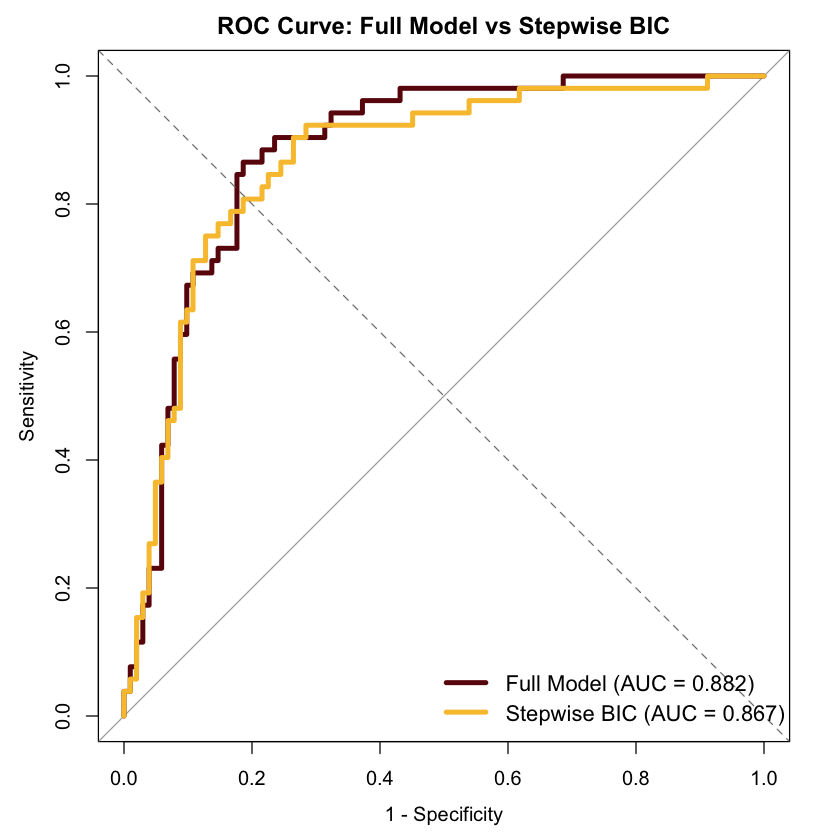

In [39]:
par(bg = "White")

plot(
  roc_full,
  col = Garnet,
  lwd = 4,
  legacy.axes = TRUE,
  main = "ROC Curve: Full Model vs Stepwise BIC"
)

plot(
  roc_step,
  add = TRUE,
  col = Gold,
  lwd = 4
)

abline(
  0,
  1,
  lty = 2,
  col = "gray50"
)

legend(
  "bottomright",
  legend = c(
    paste0(
      "Full Model (AUC = ",
      round(auc(roc_full), 3),
      ")"
    ),
    paste0(
      "Stepwise BIC (AUC = ",
      round(auc(roc_step), 3),
      ")"
    )
  ),
  col = c(Garnet, Gold),
  lwd = 4,
  cex = 1.1,
  bty = "n"
)